In [7]:
Для реалізації інтерактивності використано вбудовані віджети matplotlib.widgets, а для фільтрації — низькочастотний фільтр Баттерворта (scipy.signal.butter), який чудово згладжує високочастотний шум.

Щоб шум не генерувався наново при зміні параметрів гармоніки, чистий випадковий розподіл генерується один раз і масштабується за допомогою математичних операцій залежно від слайдерів.
    

SyntaxError: invalid character '—' (U+2014) (3788543819.py, line 1)


                  ІНСТРУКЦІЯ КОРИСТУВАЧА
1. Використовуйте слайдери 'Amplitude', 'Frequency', 'Phase' для зміни
   параметрів чистої гармоніки (синя пунктирна лінія).
2. Слайдери 'Noise Mean' та 'Noise Covariance' керують математичним 
   зсувом та дисперсією шуму накладеного на сигнал.
3. Слайдер 'Cutoff Frequency' налаштовує частоту зрізу фільтра
   Баттерворта. Менша частота сильніше згладжує графік (пурпурна лінія).
4. Чекбокс 'Show Noise' вмикає/вимикає помаранчевий зашумлений графік.
5. Чекбокс 'Show Filter' керує видимістю відфільтрованого сигналу.
6. Кнопка 'Reset' повертає всі повзунки до початкових значень.



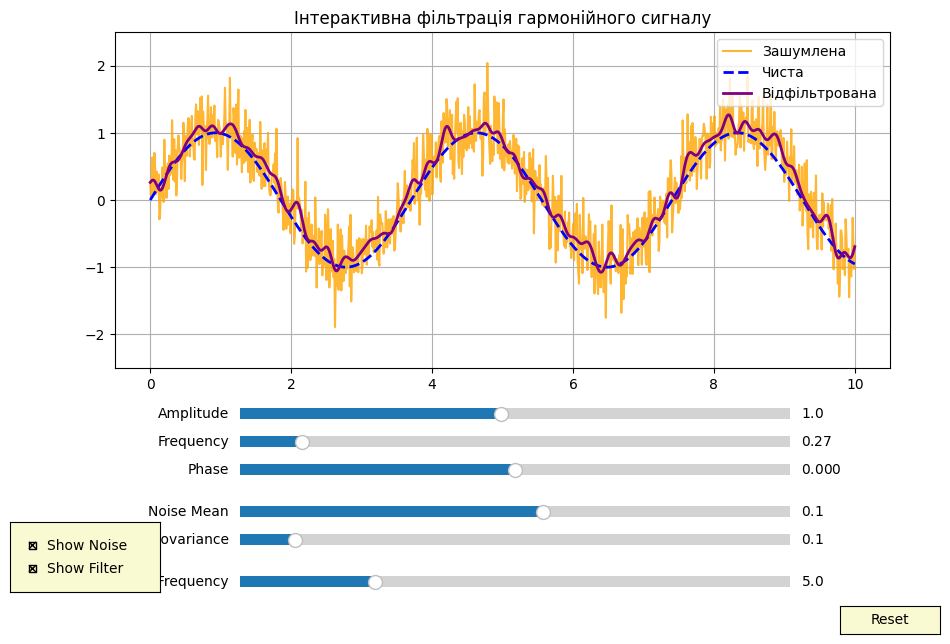

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button, CheckButtons
from scipy.signal import butter, filtfilt

# --- 1. Початкові параметри ---
INIT_AMP = 1.0
INIT_FREQ = 0.27
INIT_PHASE = 0.0
INIT_MEAN = 0.1
INIT_COV = 0.1  # Дисперсія шуму (сигма квадрат)
INIT_CUTOFF = 5.0

t = np.linspace(0, 10, 1000)

# Фіксований базовий шум (щоб він не перегенерувався повністю при зміні гармоніки)
# Генерація стандартного нормального розподілу N(0, 1)
np.random.seed(42) 
base_noise = np.random.normal(0, 1, len(t))

# --- 2. Функції обчислення ---
def get_harmonic(amplitude, frequency, phase):
    """Обчислення чистої гармоніки: y(t) = A * sin(w * t + phi)"""
    # 2 * pi додано для коректного фізичного сприйняття частоти
    return amplitude * np.sin(2 * np.pi * frequency * t + phase)

def get_noise(mean, covariance):
    """Трансформація базового шуму під задане середнє та дисперсію"""
    std_dev = np.sqrt(covariance)
    return mean + base_noise * std_dev

def butter_lowpass_filter(data, cutoff, fs, order=5):
    """Низькочастотний фільтр Баттерворта"""
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    # Перевірка меж для уникнення помилок фільтрації
    if normal_cutoff >= 1.0:
        normal_cutoff = 0.99
    elif normal_cutoff <= 0.0:
        return data
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data)

# --- 3. Ініціалізація даних ---
y_harmonic = get_harmonic(INIT_AMP, INIT_FREQ, INIT_PHASE)
current_noise = get_noise(INIT_MEAN, INIT_COV)
y_noisy = y_harmonic + current_noise

# Частота дискретизації для фільтра
fs = 1 / (t[1] - t[0]) 
y_filtered = butter_lowpass_filter(y_noisy, INIT_CUTOFF, fs)

# --- 4. Побудова інтерфейсу (Matplotlib) ---
fig, ax = plt.subplots(figsize=(10, 7))
plt.subplots_adjust(bottom=0.4)  # Залишаємо місце знизу для слайдерів

# Графіки
line_noisy, = ax.plot(t, y_noisy, color='orange', alpha=0.8, label='Зашумлена')
line_harmonic, = ax.plot(t, y_harmonic, color='blue', linestyle='--', linewidth=2, label='Чиста')
line_filtered, = ax.plot(t, y_filtered, color='purple', linewidth=2, label='Відфільтрована')

ax.set_ylim(-2.5, 2.5)
ax.grid(True)
ax.legend(loc='upper right')
ax.set_title("Інтерактивна фільтрація гармонійного сигналу")

# --- 5. Додавання віджетів (Слайдери та кнопки) ---
# Колір елементів інтерфейсу
ax_color = 'lightgoldenrodyellow'

# Слайдери гармоніки
ax_amp = plt.axes([0.25, 0.32, 0.55, 0.03], facecolor=ax_color)
ax_freq = plt.axes([0.25, 0.28, 0.55, 0.03], facecolor=ax_color)
ax_phase = plt.axes([0.25, 0.24, 0.55, 0.03], facecolor=ax_color)

s_amp = Slider(ax_amp, 'Amplitude', 0.1, 2.0, valinit=INIT_AMP)
s_freq = Slider(ax_freq, 'Frequency', 0.05, 2.0, valinit=INIT_FREQ)
s_phase = Slider(ax_phase, 'Phase', -np.pi, np.pi, valinit=INIT_PHASE)

# Слайдери шуму
ax_mean = plt.axes([0.25, 0.18, 0.55, 0.03], facecolor=ax_color)
ax_cov = plt.axes([0.25, 0.14, 0.55, 0.03], facecolor=ax_color)

s_mean = Slider(ax_mean, 'Noise Mean', -1.0, 1.0, valinit=INIT_MEAN)
s_cov = Slider(ax_cov, 'Noise Covariance', 0.0, 1.0, valinit=INIT_COV)

# Слайдер фільтра
ax_cutoff = plt.axes([0.25, 0.08, 0.55, 0.03], facecolor=ax_color)
s_cutoff = Slider(ax_cutoff, 'Cutoff Frequency', 0.1, 20.0, valinit=INIT_CUTOFF)

# Чекбокси (Показ шуму та показ фільтра)
ax_check = plt.axes([0.02, 0.08, 0.15, 0.10], facecolor=ax_color)
chk_buttons = CheckButtons(ax_check, ('Show Noise', 'Show Filter'), (True, True))

# Кнопка Reset
ax_reset = plt.axes([0.85, 0.02, 0.1, 0.04])
btn_reset = Button(ax_reset, 'Reset', color=ax_color, hovercolor='0.975')

# --- 6. Логіка оновлення ---
show_noise_flag = True
show_filter_flag = True

def update(val):
    global current_noise, show_noise_flag, show_filter_flag
    
    # Зчитуємо значення зі слайдерів
    amp = s_amp.val
    freq = s_freq.val
    phase = s_phase.val
    mean = s_mean.val
    cov = s_cov.val
    cutoff = s_cutoff.val
    
    # Обчислюємо чисту гармоніку
    y_harm = get_harmonic(amp, freq, phase)
    line_harmonic.set_ydata(y_harm)
    
    # Обчислюємо новий шум та зашумлений сигнал
    current_noise = get_noise(mean, cov)
    y_nsy = y_harm + current_noise
    
    # Фільтруємо
    y_filt = butter_lowpass_filter(y_nsy, cutoff, fs)
    
    # Відображення відповідно до чекбоксів
    if show_noise_flag:
        line_noisy.set_ydata(y_nsy)
        line_noisy.set_visible(True)
    else:
        line_noisy.set_visible(False)
        
    if show_filter_flag:
        line_filtered.set_ydata(y_filt)
        line_filtered.set_visible(True)
    else:
        line_filtered.set_visible(False)
        
    fig.canvas.draw_idle()

# Зв'язуємо слайдери з функцією оновлення
s_amp.on_changed(update)
s_freq.on_changed(update)
s_phase.on_changed(update)
s_mean.on_changed(update)
s_cov.on_changed(update)
s_cutoff.on_changed(update)

# Обробка перемикання чекбоксів
def handle_check(label):
    global show_noise_flag, show_filter_flag
    if label == 'Show Noise':
        show_noise_flag = not show_noise_flag
    elif label == 'Show Filter':
        show_filter_flag = not show_filter_flag
    update(None)

chk_buttons.on_clicked(handle_check)

# Обробка кнопки Reset
def reset(event):
    s_amp.reset()
    s_freq.reset()
    s_phase.reset()
    s_mean.reset()
    s_cov.reset()
    s_cutoff.reset()
    
btn_reset.on_clicked(reset)

# --- 7. Інструкція користувача ---
print("""
======================================================================
                  ІНСТРУКЦІЯ КОРИСТУВАЧА
======================================================================
1. Використовуйте слайдери 'Amplitude', 'Frequency', 'Phase' для зміни
   параметрів чистої гармоніки (синя пунктирна лінія).
2. Слайдери 'Noise Mean' та 'Noise Covariance' керують математичним 
   зсувом та дисперсією шуму накладеного на сигнал.
3. Слайдер 'Cutoff Frequency' налаштовує частоту зрізу фільтра
   Баттерворта. Менша частота сильніше згладжує графік (пурпурна лінія).
4. Чекбокс 'Show Noise' вмикає/вимикає помаранчевий зашумлений графік.
5. Чекбокс 'Show Filter' керує видимістю відфільтрованого сигналу.
6. Кнопка 'Reset' повертає всі повзунки до початкових значень.
======================================================================
""")

plt.show()

In [ ]:
Особливості цієї реалізації:
Збереження стану шуму: Шум генерується через масив base_noise один раз при запуску. При зміні параметрів гармоніки він не перераховується рандомно (графік "не стрибає"). При зміні слайдерів шуму він лише лінійно масштабується за формулою mean + base_noise * sqrt(covariance).

Якісна фільтрація: Використовується цифровий фільтр filtfilt (двопрохідний фільтр), який не створює фазового зсуву (затримки сигналу), що дозволяє ідеально накласти відфільтровану лінію на початкову чисту гармоніку.

Гнучкість інтерфейсу: Додано окремий чекбокс для фільтра та слайдер регулювання частоти зрізу, щоб користувач міг наочно підібрати параметри, за яких відфільтрована лінія стає максимально близькою до чистої.